## Process

In [1]:
from evolvepro.src.process import generate_wt, generate_single_aa_mutants
generate_wt('MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNTSSSPQPKKKPLDGEYFTLQIRGRERFEMFRELNEALELKDAQAGKEPGGSRAHSSHLKSKKGQSTSRHKKLMFKTEGPDSD', output_file='/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_WT_m.fasta')
generate_single_aa_mutants('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_WT_m.fasta', output_file='/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta')

Number of mutants: 7468


In [50]:
from evolvepro.src.process import suggest_initial_mutants
suggest_initial_mutants('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta', num_mutants=12, random_seed=None)


Suggested 12 mutants for testing:
1. N29R
2. Q100K
3. Y107A
4. S6T
5. S95E
6. I232E
7. A86E
8. A119T
9. P89D
10. E224M
11. G360M
12. S260Y


In [7]:
import pandas as pd
df_labels = pd.read_csv('/home/tigem/m.livero/Desktop/EvolvePro/try_1/giacomelli_mio/giacomelli_labels.csv')
voi = 'K291T','K291P','K291L','K101L','K292P','K321W','K321H','A138G','K291W','K291V'
activity = df_labels[df_labels['variant'].isin(voi)]
print(activity)

     hgvs_pro PROVEAN PPH2_HumVar PPH2_HumDiv  Grantham  BLOSUM62 PhD_SNP  \
1889    K101L   -1416         488          27       107        -2     336   
2588    A138G   -3562         991         998        60         0     642   
5499    K291L   -5138         893         821       107        -2     282   
5502    K291P   -3926         972         997       103        -1     525   
5506    K291T   -3723         947         972        78        -1     357   
5507    K291V   -4921         808         924        97        -2     268   
5508    K291W   -5698         997           1       110        -3     419   
5521    K292P   -2798         551        0,76       103        -1     433   
6067    K321H   -1509         985           1        32        -1     271   
6078    K321W   -3938         993           1       110        -3     283   

     PANTHER SNPs&GO FATHMM  ... phyloP  phastCons DMS_WT_Nutlin  \
1889     NaN     883  -6,58  ...    NaN        NaN   0,195144548   
2588     835    

## PLM

In [ ]:
!python /home/tigem/m.livero/Desktop/EvolvePro/evolvepro/plm/esm/extract.py esm1b_t33_650M_UR50S /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/giacomelli_single_mutants_m.fasta /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/output_plm/giacomelli_esm1b_t33_650M_UR50S --toks_per_batch 512 --include mean --concatenate_dir /home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/output/output_plm

## Run EVOLVEpro

In [3]:
from evolvepro.src.evolve import evolve_experimental, directed_evolution_simulation, grid_search
from evolvepro.src.data import load_dms_data,load_experimental_embeddings,load_experimental_data,create_iteration_dataframes

protein_name = 'giacomelli'
embeddings_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/try_1/giacomelli_mio/'
embeddings_file_name = 'giacomelli_esm2_t33_650M_UR50D.csv'
round_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/try_1/giacomelli_mio/2nd_replicate'
wt_fasta_path = "/home/tigem/m.livero/Desktop/EvolvePro/try_1/giacomelli_mio/giacomelli_WT_m.fasta"
number_of_variants = 10
output_dir = '/home/tigem/m.livero/Desktop/EvolvePro/try_1/giacomelli_mio/2nd_replicate'
rename_WT = False

#### Round 1

In [6]:
round_name = 'Round1'
round_file_names = ['giacomelli_round1_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round1
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
iteration shape: (10, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7438,)

Tested variants in this round: 10
15      A119T
420      A86E
1168    E224M
2511    I232E
4022     N29R
4866     P89D
4948    Q100K
6323      S6T
6368     S95E
7296    Y107A
Name: variant, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
6349    S94E  0.622925       NaN              NaN              NaN   
6367    S95D  0.568354       NaN              NaN              NaN   
6348    S94D  0.534407       NaN              NaN              NaN   
6329    S90D  0.520271       NaN              NaN              NaN   
6387    S96E  0.495805       NaN              NaN              NaN   
6330    S90E  0.495591       NaN              NaN              NaN   
5209     Q5E  0.492768       NaN              NaN 

#### Round 2

In [ ]:
round_name = 'Round2'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round2
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
iteration shape: (20, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7428,)

Tested variants in this round: 20
15      A119T
420      A86E
1168    E224M
2511    I232E
4022     N29R
4866     P89D
4948    Q100K
5209      Q5E
5855    S183E
6323      S6T
6329     S90D
6330     S90E
6348     S94D
6349     S94E
6367     S95D
6368     S95E
6386     S96D
6387     S96E
7261     W91E
7296    Y107A
Name: variant, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
5873   S185D  0.894277       NaN              NaN              NaN   
5797   S149D  0.803634       NaN              NaN              NaN   
5854   S183D  0.764727       NaN              NaN              NaN   
5740   S116D  0.735438       NaN              NaN       

#### Round 3

In [12]:
round_name = 'Round3'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round3
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
iteration shape: (30, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7418,)

Tested variants in this round: 30
15      A119T
420      A86E
1168    E224M
2511    I232E
3118    L188D
3175    L206D
3898    N235E
4022     N29R
4866     P89D
4948    Q100K
5209      Q5E
5722    S106E
5740    S116D
5797    S149D
5854    S183D
5855    S183E
5873    S185D
5874    S185E
6323      S6T
6329     S90D
6330     S90E
6348     S94D
6349     S94E
6367     S95D
6368     S95E
6386     S96D
6387     S96E
6406     S99E
7261     W91E
7296    Y107A
Name: variant, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
6405    S99D  0.715355       NaN              NaN             

#### Round 4

In [14]:
round_name = 'Round4'
round_file_names = [ 'giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round4
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
iteration shape: (40, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7408,)

Tested variants in this round: 40
2       A119E
15      A119T
97      A189E
173     A353E
420      A86E
1168    E224M
2511    I232E
2643    K120D
2701    K164E
3118    L188D
3175    L206D
3176    L206E
3898    N235E
4022     N29R
4259    P190E
4866     P89D
4948    Q100K
5209      Q5E
5722    S106E
5740    S116D
5759    S121D
5797    S149D
5854    S183D
5855    S183E
5873    S185D
5874    S185E
6323      S6T
6329     S90D
6330     S90E
6348     S94D
6349     S94E
6367     S95D
6368     S95E
6386     S96D
6387     S96E
6405     S99D
6406     S99E
6501    T125E
7261     W91E
7296    Y

#### Round 5

In [16]:
round_name = 'Round5'
round_file_names = [ 'giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx',
                     'giacomelli_round5_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round5
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5_2r.xlsx: (10, 3)
iteration shape: (50, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7398,)

Tested variants in this round: 50
1       A119D
2       A119E
15      A119T
21      A129E
97      A189E
173     A353E
181     A353N
211     A364E
230      A39E
257      A63N
295      A70N
420      A86E
1168    E224M
1998    G262E
2169    G361E
2511    I232E
2643    K120D
2701    K164E
3118    L188D
3119    L188E
3175    L206D
3176    L206E
3898    N235E
4022     N29R
4259    P190E
4866     P89D
4948    Q100K
5209      Q5E
5722    S106E
5740    S116D
5759    S121D
5797    S149D
5854    S183D
5855    S183E
5873    S185D
5

Round 6


In [18]:
round_name = 'Round6'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx',
                     'giacomelli_round5_2r.xlsx',
                     'giacomelli_round6_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round6
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6_2r.xlsx: (10, 3)
iteration shape: (60, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7388,)

Tested variants in this round: 60
1       A119D
2       A119E
15      A119T
21      A129E
97      A189E
172     A353D
173     A353E
181     A353N
201     A355P
211     A364E
230      A39E
257      A63N
295      A70N
420      A86E
1168    E224M
1998    G262E
2169    G361E
2511    I232E
2643    K120D
2681    K139D
2701    K164E
2814    K320D
2865    K351T
2929    K373E
3118    L188D
3119    L188E
3175    L206D
3176    L206E
3708    M243E
3860    N200E
3898   

Round 7

In [21]:
round_name = 'Round7'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx',
                     'giacomelli_round5_2r.xlsx',
                     'giacomelli_round6_2r.xlsx',
                     'giacomelli_round7_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round7
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7_2r.xlsx: (10, 3)
iteration shape: (70, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7378,)

Tested variants in this round: 70
1       A119D
2       A119E
8       A119L
15      A119T
21      A129E
        ...  
6501    T125E
6539    T150E
7261     W91E
7279    Y103D
7296    Y107A
Name: variant, Length: 70, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
2856   K351H  0.792246       NaN              NaN           

Round 8

In [4]:
round_name = 'Round8'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx',
                     'giacomelli_round5_2r.xlsx',
                     'giacomelli_round6_2r.xlsx',
                     'giacomelli_round7_2r.xlsx',
                     'giacomelli_round8_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round8
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round8_2r.xlsx: (10, 3)
iteration shape: (80, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7368,)

Tested variants in this round: 80
1       A119D
2       A119E
8       A119L
15      A119T
21      A129E
        ...  
6539    T150E
6577    T170E
7261     W91E
7279    Y103D
7296    Y107A
Name: variant, Length: 80, dtype: str

Top 10 variants predicted by the model:
     variant    y_pred  y_actual  y_actual_scaled  y_actual_binary

Round 9

In [6]:
round_name = 'Round9'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx',
                     'giacomelli_round5_2r.xlsx',
                     'giacomelli_round6_2r.xlsx',
                     'giacomelli_round7_2r.xlsx',
                     'giacomelli_round8_2r.xlsx',
                     'giacomelli_round9_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round9
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round8_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round9_2r.xlsx: (10, 3)
iteration shape: (90, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7358,)

Tested variants in this round: 90
1       A119D
2       A119E
8       A119L
15      A119T
21      A129E
        ...  
6539    T150E
6577    T170E
7261     W91E
7279    Y103D
7296    Y107A
Name: variant, Length: 90, dtype: str

Top 10 variants predicted by the model:
  

Round 10

In [8]:
round_name = 'Round10'
round_file_names = ['giacomelli_round1_2r.xlsx',
                     'giacomelli_round2_2r.xlsx',
                     'giacomelli_round3_2r.xlsx',
                     'giacomelli_round4_2r.xlsx',
                     'giacomelli_round5_2r.xlsx',
                     'giacomelli_round6_2r.xlsx',
                     'giacomelli_round7_2r.xlsx',
                     'giacomelli_round8_2r.xlsx',
                     'giacomelli_round9_2r.xlsx',
                     'giacomelli_round10_2r.xlsx']

this_round_variants, df_test, df_sorted_all = evolve_experimental(
    protein_name,
    round_name,
    embeddings_base_path,
    embeddings_file_name,
    round_base_path,
    round_file_names,
    wt_fasta_path,
    rename_WT,
    number_of_variants,
    output_dir
)

Processing giacomelli - Round10
Embeddings loaded: (7448, 1280)
Loaded experimental data for giacomelli_round1_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round2_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round3_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round4_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round5_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round6_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round7_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round8_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round9_2r.xlsx: (10, 3)
Loaded experimental data for giacomelli_round10_2r.xlsx: (10, 3)
iteration shape: (100, 2)
Labels shape: (7448, 5)
Embeddings and labels are aligned
(7348,)

Tested variants in this round: 100
1       A119D
2       A119E
8       A119L
15      A119T
21      A129E
        ...  
6539    T150E
6577    T170E
7261     W91E
7279    Y103D
7296    Y107A
Name: variant

## Plot

In [10]:
from evolvepro.src.plot import read_exp_data, plot_variants_by_iteration

round_base_path = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate'
round_file_names = ['giacomelli_round1_3r.xlsx',
                     'giacomelli_round2_3r.xlsx',
                     'giacomelli_round3_3r.xlsx',
                     'giacomelli_round4_3r.xlsx',
                     'giacomelli_round5_3r.xlsx',
                     'giacomelli_round6_3r.xlsx',
                     'giacomelli_round7_3r.xlsx',
                     'giacomelli_round8_3r.xlsx',
                     'giacomelli_round9_3r.xlsx',
                     'giacomelli_round10_3r.xlsx']
wt_fasta_path = "/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/giacomelli_WT_m.fasta"

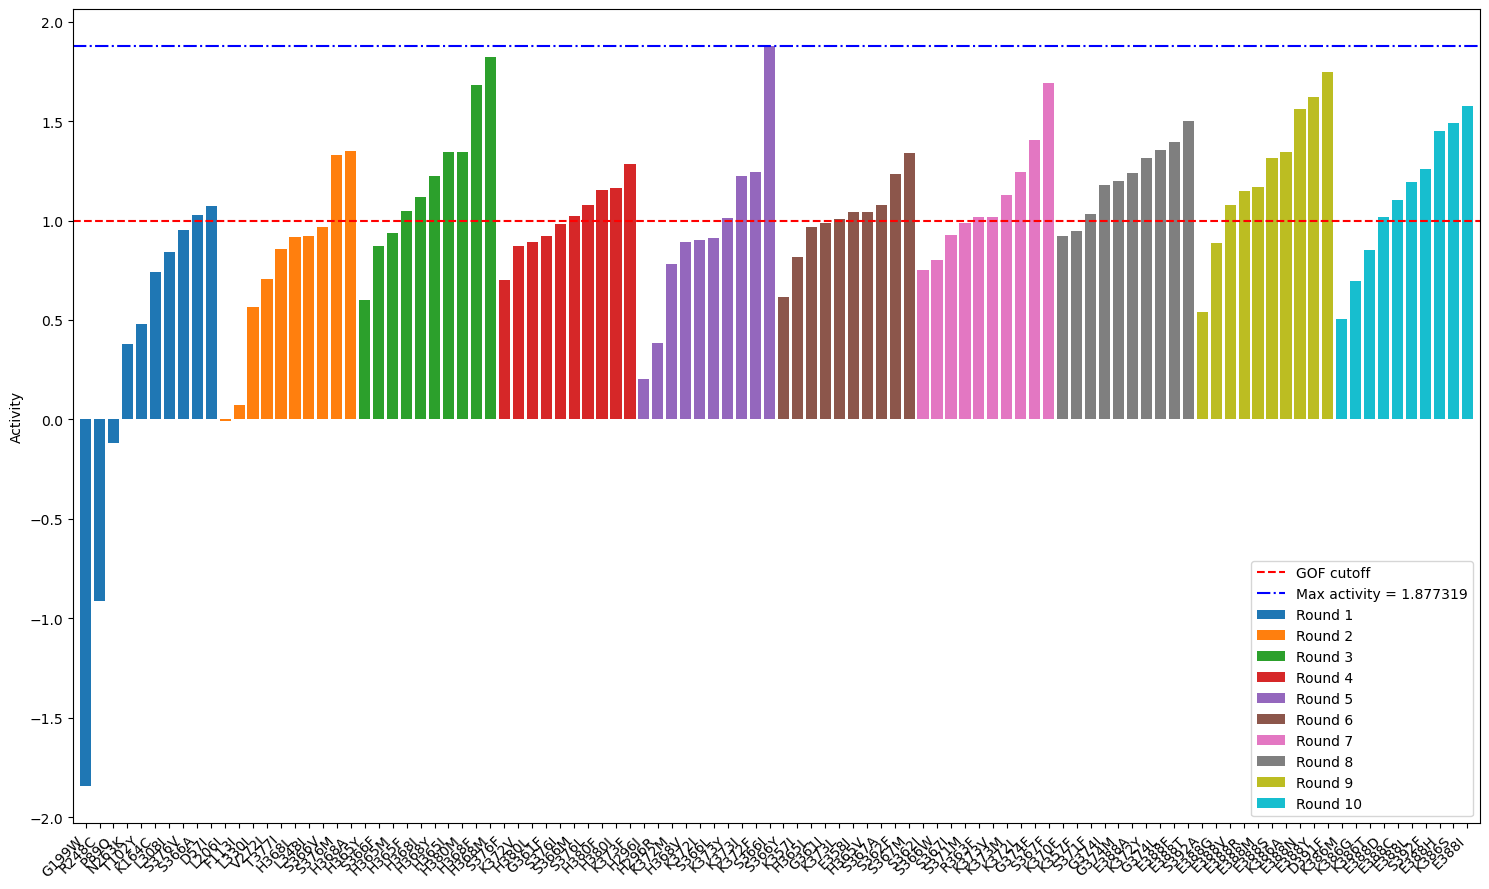

In [11]:
df = read_exp_data(round_base_path, round_file_names, wt_fasta_path)
plot_variants_by_iteration(df, activity_column='activity', output_dir='/home/tigem/m.livero/Desktop/EvolvePro/try_1/giacomelli_mio/2nd_replicate/giacomelli', output_file="giacomelli_2nd")


In [12]:
from evolvepro.src.metrics_functions import load_dataset, enrichment_factor, apk
path_labels = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/giacomelli_labels.csv'


In [ ]:
#round1
round_path_1 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round1/df_sorted_all.csv'
df_giacomelli_1 = load_dataset(round_path_1, path_labels, threshold_hit=1.0)
ef_r1 = enrichment_factor(df_giacomelli_1, fraction=0.1)
ap_10_r1 = apk(df_giacomelli_1, k=10)
print(f'Enrichment Factor(0.1) Round 1: {ef_r1}')
print(f'Average Precision@10 Round 1: {ap_10_r1}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0    D57I  0.816761  1.071073         1.000000              1.0   
1           1   S366A  0.746238  1.026297         0.984639              1.0   
2           2   T377I  0.697596       NaN              NaN              NaN   
3           3   S376V  0.691914  0.950571         0.958661              0.0   
4           4   L308I  0.659034  0.843962         0.922088              0.0   
5           5   S366V  0.654469       NaN              NaN              NaN   
6           6   L348I  0.652868       NaN              NaN              NaN   
7           7   H368A  0.629222       NaN              NaN              NaN   
8           8   S376M  0.628945       NaN              NaN              NaN   
9           9   H368L  0.622329       NaN              NaN              NaN   

   dist_metric  std_predictions  activity  activity_binary  
0     0.029400              0.0  1.071073                1  
1     0.

In [14]:
#round2
round_path_2 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round2/df_sorted_all.csv'
df_giacomelli_2 = load_dataset(round_path_2, path_labels, threshold_hit=1.0)
ef_r2 = enrichment_factor(df_giacomelli_2, fraction=0.1)
ap_10_r2 = apk(df_giacomelli_2, k=10)
print(f'Enrichment Factor(0.1) Round 2: {ef_r2}')
print(f'Average Precision@10 Round 2: {ap_10_r2}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368A  1.135378  1.348083         1.000000              1.0   
1           1   S376M  1.108700  1.329756         0.994258              1.0   
2           2   H368I  1.017112       NaN              NaN              NaN   
3           3   H368M  1.002429       NaN              NaN              NaN   
4           4   H368F  1.001760       NaN              NaN              NaN   
5           5   S366V  0.995188  0.965372         0.880103              0.0   
6           6   S366A  0.988502  1.026297         0.899190              1.0   
7           7   H380M  0.986195       NaN              NaN              NaN   
8           8   H368L  0.983676  0.917759         0.865186              0.0   
9           9   H368Y  0.964835       NaN              NaN              NaN   

   dist_metric  std_predictions  activity  activity_binary  
0     0.026224              0.0  1.348083                1  
1     0.

In [15]:
#round3
round_path_3 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round3/df_sorted_all.csv'
df_giacomelli_3 = load_dataset(round_path_3, path_labels, threshold_hit=1.0)
ef_r3 = enrichment_factor(df_giacomelli_3, fraction=0.1)
ap_10_r3 = apk(df_giacomelli_3, k=10)
print(f'Enrichment Factor(0.1) Round 3: {ef_r3}')
print(f'Average Precision@10 Round 3: {ap_10_r3}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.591785  1.821861         1.000000              1.0   
1           1   H368F  1.480388  1.681469         0.961702              1.0   
2           2   H380M  1.239345  1.346850         0.870420              1.0   
3           3   H365I  1.204351  1.342151         0.869138              1.0   
4           4   S376M  1.167314  1.329756         0.865757              1.0   
5           5   H368Y  1.138511  1.224364         0.837006              1.0   
6           6   H380I  1.126796       NaN              NaN              NaN   
7           7   S366M  1.120291       NaN              NaN              NaN   
8           8   H380L  1.104438       NaN              NaN              NaN   
9           9   H368I  1.089877  1.117034         0.807727              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.043143              0.0  1.821861                1  
1     0.

In [16]:
#round4
round_path_4 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round4/df_sorted_all.csv'
df_giacomelli_4 = load_dataset(round_path_4, path_labels, threshold_hit=1.0)
ef_r4 = enrichment_factor(df_giacomelli_4, fraction=0.1)
ap_10_r4 = apk(df_giacomelli_4, k=10)
print(f'Enrichment Factor(0.1) Round 4: {ef_r4}')
print(f'Average Precision@10 Round 4: {ap_10_r4}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.641466  1.821861         1.000000              1.0   
1           1   H368F  1.506197  1.681469         0.961702              1.0   
2           2   H365I  1.253926  1.342151         0.869138              1.0   
3           3   H368A  1.214353  1.348083         0.870756              1.0   
4           4   K373F  1.206417  1.285168         0.853593              1.0   
5           5   H368I  1.192527  1.117034         0.807727              1.0   
6           6   H380M  1.179142  1.346850         0.870420              1.0   
7           7   H380I  1.150201  1.164825         0.820764              1.0   
8           8   H368Y  1.129365  1.224364         0.837006              1.0   
9           9   S376M  1.128738  1.329756         0.865757              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.044244              0.0  1.821861                1  
1     0.

In [17]:
#round5
round_path_5 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round5/df_sorted_all.csv'
df_giacomelli_5 = load_dataset(round_path_5, path_labels, threshold_hit=1.0)
ef_r5 = enrichment_factor(df_giacomelli_5, fraction=0.1)
ap_10_r5 = apk(df_giacomelli_5, k=10)
print(f'Enrichment Factor(0.1) Round 5: {ef_r5}')
print(f'Average Precision@10 Round 5: {ap_10_r5}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   S366I  1.650878  1.877319         1.000000              1.0   
1           1   H368M  1.586929  1.821861         0.985097              1.0   
2           2   H368F  1.410930  1.681469         0.947370              1.0   
3           3   H365I  1.305082  1.342151         0.856185              1.0   
4           4   H380M  1.251743  1.346850         0.857448              1.0   
5           5   H368I  1.225482  1.117034         0.795690              1.0   
6           6   K373F  1.199694  1.285168         0.840872              1.0   
7           7   S376M  1.191247  1.329756         0.852854              1.0   
8           8   K373I  1.173643  1.224399         0.824542              1.0   
9           9   H368Y  1.169246  1.224364         0.824532              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.037250              0.0  1.877319                1  
1     0.

In [19]:
#round6
round_path_6 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round6/df_sorted_all.csv'
df_giacomelli_6 = load_dataset(round_path_6, path_labels, threshold_hit=1.0)
ef_r6 = enrichment_factor(df_giacomelli_6, fraction=0.1)
ap_10_r6 = apk(df_giacomelli_6, k=10)
print(f'Enrichment Factor(0.1) Round 6: {ef_r6}')
print(f'Average Precision@10 Round 6: {ap_10_r6}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.583504  1.821861         0.985097              1.0   
1           1   S366I  1.512513  1.877319         1.000000              1.0   
2           2   H368F  1.467217  1.681469         0.947370              1.0   
3           3   H365I  1.301809  1.342151         0.856185              1.0   
4           4   H380M  1.255653  1.346850         0.857448              1.0   
5           5   S376M  1.209795  1.329756         0.852854              1.0   
6           6   K373F  1.207138  1.285168         0.840872              1.0   
7           7   H368I  1.195178  1.117034         0.795690              1.0   
8           8   S367M  1.172478  1.341405         0.855985              1.0   
9           9   K372F  1.147985  1.245655         0.830254              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.046313              0.0  1.821861                1  
1     0.

In [20]:
#round7
round_path_7 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round7/df_sorted_all.csv'
df_giacomelli_7 = load_dataset(round_path_7, path_labels, threshold_hit=1.0)
ef_r7 = enrichment_factor(df_giacomelli_7, fraction=0.1)
ap_10_r7 = apk(df_giacomelli_7, k=10)
print(f'Enrichment Factor(0.1) Round 7: {ef_r7}')
print(f'Average Precision@10 Round 7: {ap_10_r7}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.588483  1.821861         0.985097              1.0   
1           1   S366I  1.523184  1.877319         1.000000              1.0   
2           2   H368F  1.472053  1.681469         0.947370              1.0   
3           3   S367F  1.429787  1.690890         0.949901              1.0   
4           4   G374F  1.322876  1.402410         0.872378              1.0   
5           5   H365I  1.273578  1.342151         0.856185              1.0   
6           6   K373F  1.238603  1.285168         0.840872              1.0   
7           7   S367M  1.233385  1.341405         0.855985              1.0   
8           8   S376M  1.225639  1.329756         0.852854              1.0   
9           9   H380M  1.206549  1.346850         0.857448              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.046313              0.0  1.821861                1  
1     0.

In [21]:
#round5
round_path_8 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round8/df_sorted_all.csv'
df_giacomelli_8 = load_dataset(round_path_8, path_labels, threshold_hit=1.0)
ef_r8 = enrichment_factor(df_giacomelli_8, fraction=0.1)
ap_10_r8 = apk(df_giacomelli_8, k=10)
print(f'Enrichment Factor(0.1) Round 8: {ef_r8}')
print(f'Average Precision@10 Round 8: {ap_10_r8}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.556573  1.821861         0.985097              1.0   
1           1   S366I  1.488585  1.877319         1.000000              1.0   
2           2   H368F  1.478465  1.681469         0.947370              1.0   
3           3   S367F  1.375017  1.690890         0.949901              1.0   
4           4   G374F  1.331747  1.402410         0.872378              1.0   
5           5   E388T  1.293347  1.500914         0.898849              1.0   
6           6   E388F  1.281645  1.395992         0.870654              1.0   
7           7   H365I  1.262552  1.342151         0.856185              1.0   
8           8   H380M  1.244075  1.346850         0.857448              1.0   
9           9   E388A  1.241123  1.238938         0.828449              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.046313              0.0  1.821861                1  
1     0.

In [22]:
#round9
round_path_9 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round9/df_sorted_all.csv'
df_giacomelli_9 = load_dataset(round_path_9, path_labels, threshold_hit=1.0)
ef_r9 = enrichment_factor(df_giacomelli_9, fraction=0.1)
ap_10_r9 = apk(df_giacomelli_9, k=10)
print(f'Enrichment Factor(0.1) Round 9: {ef_r9}')
print(f'Average Precision@10 Round 9: {ap_10_r9}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.660279  1.821861         0.985097              1.0   
1           1   H368F  1.513863  1.681469         0.947370              1.0   
2           2   S366I  1.502701  1.877319         1.000000              1.0   
3           3   E388N  1.475257  1.558262         0.914260              1.0   
4           4   E388Y  1.456779  1.619739         0.930781              1.0   
5           5   S367F  1.454091  1.690890         0.949901              1.0   
6           6   D391F  1.443985  1.748360         0.965345              1.0   
7           7   E388T  1.388753  1.500914         0.898849              1.0   
8           8   E388F  1.388492  1.395992         0.870654              1.0   
9           9   G374F  1.308268  1.402410         0.872378              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.046313              0.0  1.821861                1  
1     0.

In [23]:
#round10
round_path_10 = '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli/Round10/df_sorted_all.csv'
df_giacomelli_10 = load_dataset(round_path_10, path_labels, threshold_hit=1.0)
ef_r10 = enrichment_factor(df_giacomelli_10, fraction=0.1)
ap_10_r10 = apk(df_giacomelli_10, k=10)
print(f'Enrichment Factor(0.1) Round 10: {ef_r10}')
print(f'Average Precision@10 Round 10: {ap_10_r10}')

   Unnamed: 0 variant    y_pred  y_actual  y_actual_scaled  y_actual_binary  \
0           0   H368M  1.596443  1.821861         0.985097              1.0   
1           1   S366I  1.548940  1.877319         1.000000              1.0   
2           2   H368F  1.528954  1.681469         0.947370              1.0   
3           3   E388N  1.495084  1.558262         0.914260              1.0   
4           4   E388Y  1.476135  1.619739         0.930781              1.0   
5           5   D391F  1.457327  1.748360         0.965345              1.0   
6           6   E388I  1.448774  1.574588         0.918648              1.0   
7           7   S367F  1.446809  1.690890         0.949901              1.0   
8           8   E388T  1.414194  1.500914         0.898849              1.0   
9           9   E388F  1.400282  1.395992         0.870654              1.0   

   dist_metric  std_predictions  activity  activity_binary  
0     0.046313              0.0  1.821861                1  
1     0.

In [24]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
rounds = ['Round 1', 'Round 2', 'Round 3', 'Round 4', 'Round 5', 'Round 6', 'Round 7', 'Round 8', 'Round 9', 'Round 10']
ef_values = [ef_r1, ef_r2, ef_r3, ef_r4, ef_r5, ef_r6, ef_r7, ef_r8, ef_r9, ef_r9]
apk_values = [ap_10_r1, ap_10_r2, ap_10_r3, ap_10_r4, ap_10_r5, ap_10_r6, ap_10_r7, ap_10_r8, ap_10_r9, ap_10_r10]

df_metrics= pd.DataFrame({'Rounds': rounds, 
                          'ef_values_2nd': ef_values,
                          'apk_values_2nd':apk_values})
print(df_metrics.head(10))
os.makedirs('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate', exist_ok=True)
df_metrics_2nd = df_metrics.to_csv('/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/giacomelli_mio/try_1/3rd_replicate/giacomelli_metrics_3rd', encoding='utf-8', index = False)

     Rounds  ef_values_2nd  apk_values_2nd
0   Round 1       1.515440        0.003115
1   Round 2       2.101705        0.008323
2   Round 3       1.924719        0.009834
3   Round 4       1.991089        0.011050
4   Round 5       2.123828        0.011050
5   Round 6       2.378245        0.011050
6   Round 7       2.378245        0.011050
7   Round 8       2.566292        0.011050
8   Round 9       2.356122        0.011050
9  Round 10       2.356122        0.011050


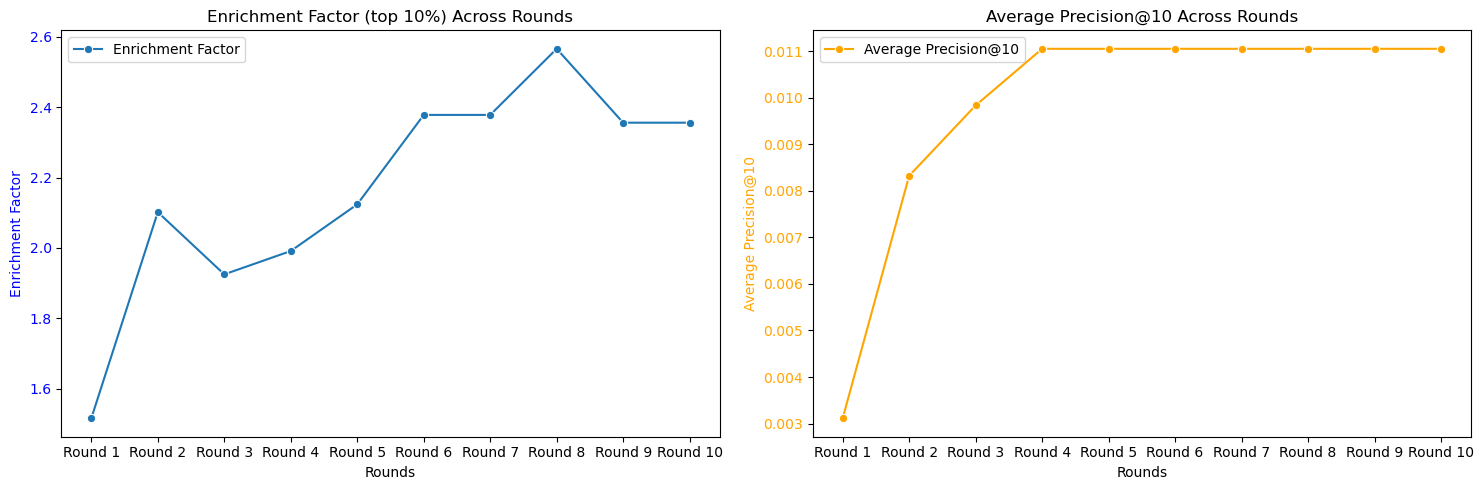

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(15, 5))
sns.lineplot(x=rounds, y=ef_values, marker='o', label='Enrichment Factor', ax=ax1)
ax1.set_title('Enrichment Factor (top 10%) Across Rounds')
ax1.set_xlabel('Rounds')
ax1.set_ylabel('Enrichment Factor', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


sns.lineplot(x=rounds, y=apk_values, marker='o', label='Average Precision@10', ax=ax2, color='orange')
ax2.set_title('Average Precision@10 Across Rounds')
ax2.set_xlabel('Rounds')
ax2.set_ylabel('Average Precision@10', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
fig.tight_layout()
plt.savefig(
    '/home/tigem/m.livero/Desktop/EvolvePro/giacomelli/EF_APK_giacomelli_mio.png', 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()